In [38]:
#data and visuals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import datetime


#modelling
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Imputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

pd.options.display.max_rows = 4000

In [25]:
#user defined lists
segments = ["Cheap + Comfy","Cheap + Curious","Curious","Comfy","Craver","Caviar"]
segments2 = ["Assigned Segment." + i for i in segments]

bain_10questions = [
    'I always choose higher end hotels',
    'On vacation I pride myself on discovering new places and things my friends have not seen before',
    'I choose more expensive hotels and accommodations to make sure I get the best service and amenities',
    'It is important for me to be in a luxurious setting and to be pampered on vacation',
    'I like to immerse myself in the local culture when on vacation',
    'The difference between luxury and standard hotels just is not big enough to justify the cost',
    'I always pay more for a higher class of room on my vacations',
    'I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation',
    'I think spending more for unique experiences is part of what makes a vacation special',
    'I like to go on vacations that are off the beaten path'
]

In [94]:
#user defined functions

#Function: multi_pred_enricher
def multi_pred_enricher(preds):
    """
    Purpose: transform multi-output prediction array into dataframe with predicted Bain segment
    """
    preds = pd.DataFrame(preds)
    preds.columns = segments2
    preds = preds[segments2]
    preds['Assigned Segment'] = ""
    preds['Assigned Segment (Model Value)'] = 0
    for i in segments2:
        #Assign segment if resulting model value is the maximum resulting value
        preds.loc[:,'Assigned Segment'] = np.where(
            preds['Assigned Segment (Model Value)'] >= preds[i], preds['Assigned Segment'], i)
        preds.loc[:,'Assigned Segment (Model Value)'] = np.where(
            preds['Assigned Segment'] == i, preds[i], preds['Assigned Segment (Model Value)'])

    preds['Assigned Segment'] = preds['Assigned Segment'].map(lambda x: x.lstrip('Assigned Segment.'))   
    
    return preds

#Function: multi_pred_score_visualizer
def multi_pred_score_visualizer(actual, preds):
    score = np.mean(actual == preds)
    cm = metrics.confusion_matrix(actual, preds)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r'
               ,xticklabels = ["Caviar", "Cheap + Comfy","Cheap + Curious","Comfy","Craver","Curious"]
               ,yticklabels = ["Caviar", "Cheap + Comfy","Cheap + Curious","Comfy","Craver","Curious"]
               );
    plt.ylabel('Actual label');
    plt.xlabel('Predicted label');
    all_sample_title = 'Accuracy Score (test): {0}'.format(score.round(10))
    plt.suptitle(all_sample_title, size = 15);
    #plt.title('Accuracy Score (train): {0}'.format(train_score.round(10)), size = 11);
    plt.show()
    
    
def multi_feature_importance(model):
    # Plot feature importance
    feature_importance = model.feature_importances_
    # make importances relative to max importance
    feature_importance = 100.0 * (feature_importance / feature_importance.max())
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + .5
    plt.subplot(1, 2, 2)
    plt.barh(pos[-20:], feature_importance[sorted_idx][-20:], align='center')
    plt.yticks(pos[-20:], x_train_raw.columns[sorted_idx][-20:])
    plt.xlabel('Relative Importance')
    plt.title('Variable Importance')
    plt.show()
    

In [22]:
x_vars = pd.read_csv("../../data/bain_x_vars.csv")
y_vars = pd.read_csv("../../data/bain_y_vars.csv")

print("x_vars.shape:",x_vars.shape)
print("y_vars.shape:",y_vars.shape)

x_vars.shape: (616, 944)
y_vars.shape: (616, 90)


In [140]:
x_train, x_test, y_train, y_test = train_test_split(x_vars,
                                                    y_vars,
                                                    test_size=0.2, random_state=195)


In [192]:
x_train_raw = x_train
x_test_raw = x_test

train = pd.concat([x_train, y_train["Assigned Segment"]], axis = 1)
test = pd.concat([x_test, y_test["Assigned Segment"]], axis = 1)

#fill in missing data
imp = IterativeImputer(max_iter=10, random_state=0)
imp.fit(x_train)
x_train = imp.transform(x_train)
x_test = imp.transform(x_test)

print("Shape - x_train:",x_train.shape)
print("Shape - x_test:",x_test.shape)
print("Shape - y_train:",y_train.shape)
print("Shape - y_test:",y_test.shape)

Shape - x_train: (492, 944)
Shape - x_test: (124, 944)
Shape - y_train: (492, 90)
Shape - y_test: (124, 90)


C:\Users\zmerritt\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


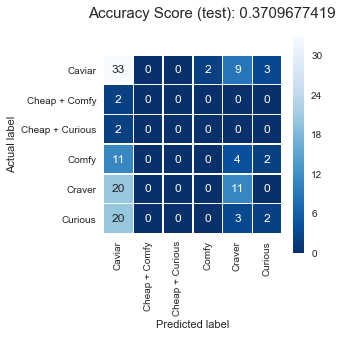

In [131]:
model = make_pipeline(IterativeImputer(max_iter=10, random_state=0),
                      StandardScaler(),
                      RandomForestClassifier(random_state=195))

model.fit(x_train, y_train['Assigned Segment'])
predictions = model.predict(x_test)
multi_pred_score_visualizer(y_test['Assigned Segment'],predictions)

In [125]:
import scipy
x_train_sparse = scipy.sparse.csr_matrix(x_train)
x_test_sparse = scipy.sparse.csr_matrix(x_test)

In [128]:
from tpot import TPOTClassifier
pipeline_optimizer = TPOTClassifier(generations=2, population_size=20, cv=5,
                                    random_state=42, verbosity=2, config_dict='TPOT sparse')
pipeline_optimizer.fit(x_train_sparse, y_train['Assigned Segment'])

Generation 1 - Current best internal CV score: 0.38829593163397974
Generation 2 - Current best internal CV score: 0.38829593163397974

Best pipeline: BernoulliNB(input_matrix, alpha=10.0, fit_prior=True)


TPOTClassifier(config_dict='TPOT sparse', crossover_rate=0.1, cv=5,
               disable_update_check=False, early_stop=None, generations=2,
               max_eval_time_mins=5, max_time_mins=None, memory=None,
               mutation_rate=0.9, n_jobs=1, offspring_size=None,
               periodic_checkpoint_folder=None, population_size=20,
               random_state=42, scoring=None, subsample=1.0,
               template='RandomTree', use_dask=False, verbosity=2,
               warm_start=False)

In [209]:
sm = SMOTE(random_state=12, sampling_strategy = 'all', k_neighbors = 12)
x_train_res, y_train_res = sm.fit_sample(x_train, y_train["Assigned Segment"])
x_train_resdf = pd.DataFrame(x_train_res)
x_train_resdf.columns = x_train_raw.columns
y_train_resdf = pd.DataFrame(y_train_res)
y_train_resdf.columns = ["Assigned Segment"]

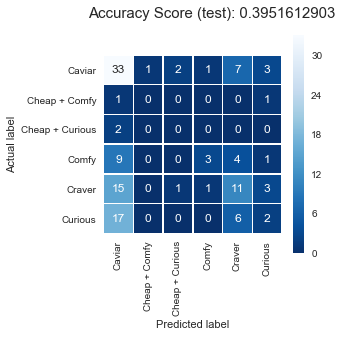

In [222]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

steps = [
    ('imputer', IterativeImputer(max_iter=10, random_state=195)),
    ('scaler', StandardScaler()),
    ('reducer', PCA(n_components = .5, svd_solver = 'full', iterated_power = 100000, whiten = True, random_state=195)),
    ('selector', SelectFromModel(LinearSVC(C=.5, penalty="l1", dual=False))),
    ('model', RandomForestClassifier(n_estimators=200,
                                     max_depth=30,
                                     min_samples_leaf = 1,
                                     random_state=195))
]

model = Pipeline(steps)

model.fit(x_train_resdf, y_train_resdf['Assigned Segment'])
predictions = model.predict(x_test)
multi_pred_score_visualizer(y_test['Assigned Segment'],predictions)

In [175]:
model.transform(x_test).shape

(124, 36)

In [172]:
model['reducer'].components_.shape

(37, 38)

In [173]:
model['model'].n_features_

37

In [141]:
x_train.isnull().sum()

home_video_recording_acxiom                                                                        0
accessories_acxiom                                                                                 0
aerobic_acxiom                                                                                     0
affairsandpolitics_acxiom                                                                          0
alcohol_wine_acxiom                                                                                0
american_history_acxiom                                                                            0
animal_welfare_acxiom                                                                              0
antiques_acxiom                                                                                    0
appliances_acxiom                                                                                  0
art_acxiom                                                                                 

In [144]:
(x_train!=0).sum()

home_video_recording_acxiom                                                                       38
accessories_acxiom                                                                                 6
aerobic_acxiom                                                                                    70
affairsandpolitics_acxiom                                                                        103
alcohol_wine_acxiom                                                                               87
american_history_acxiom                                                                            6
animal_welfare_acxiom                                                                             41
antiques_acxiom                                                                                  122
appliances_acxiom                                                                                  4
art_acxiom                                                                                 